In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

from helper_functions import eval_model
%matplotlib inline

2024-03-28 21:20:50.851399: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9373] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-28 21:20:50.851932: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-28 21:20:50.858514: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1534] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-28 21:20:50.877682: I tensorflow/core/platform/cpu_feature_guard.cc:183] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/root/.local/lib/python3.10/site-packag

In [2]:
image_size=512
batch_size=16

# since we're resizing we can rescale up here rather than in the model
def resize_and_rescale(image, label):
  image = tf.cast(image, tf.float32)
  image = tf.image.resize(image, [image_size, image_size])
  image = (image / 255.0)
  return image, label

2024-03-28 21:20:54.001599: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


tfds.core.DatasetInfo(
    name='image_folder',
    full_name='image_folder/1.0.0',
    description="""
    Generic image classification dataset.
    """,
    homepage='https://www.tensorflow.org/datasets/catalog/image_folder',
    data_dir='/root/tensorflow_datasets/image_folder/1.0.0',
    file_format=tfrecord,
    download_size=Unknown size,
    dataset_size=Unknown size,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    splits={
        'test': <SplitInfo num_examples=1320, num_shards=1>,
        'train': <SplitInfo num_examples=6160, num_shards=1>,
        'validation': <SplitInfo num_examples=1320, num_shards=1>,
    },
    citation="""""",
)


2024-03-28 21:20:54.544891: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 21:20:54.586970: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 21:20:54.587007: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 21:20:54.590140: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-03-28 21:20:54.590179: I external/local_xla/xla/stream_executor

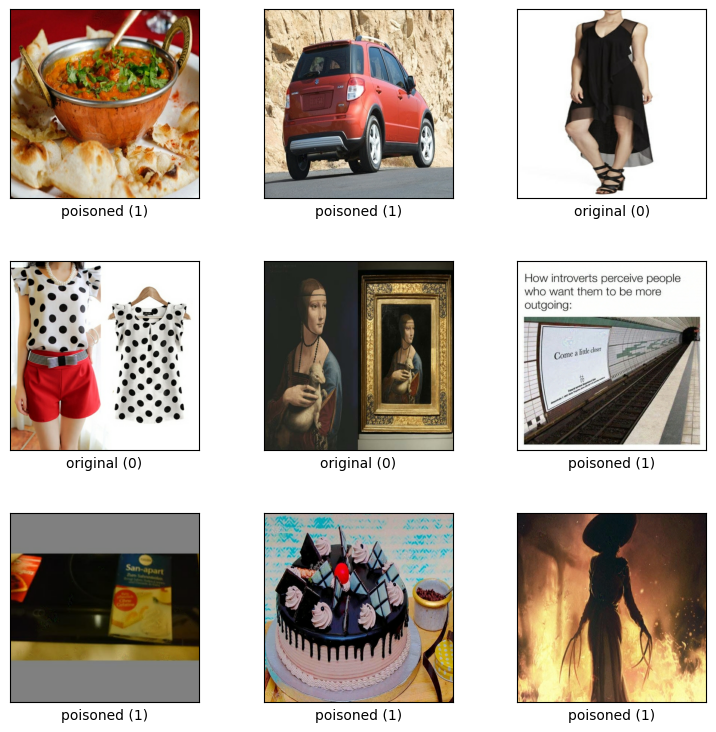

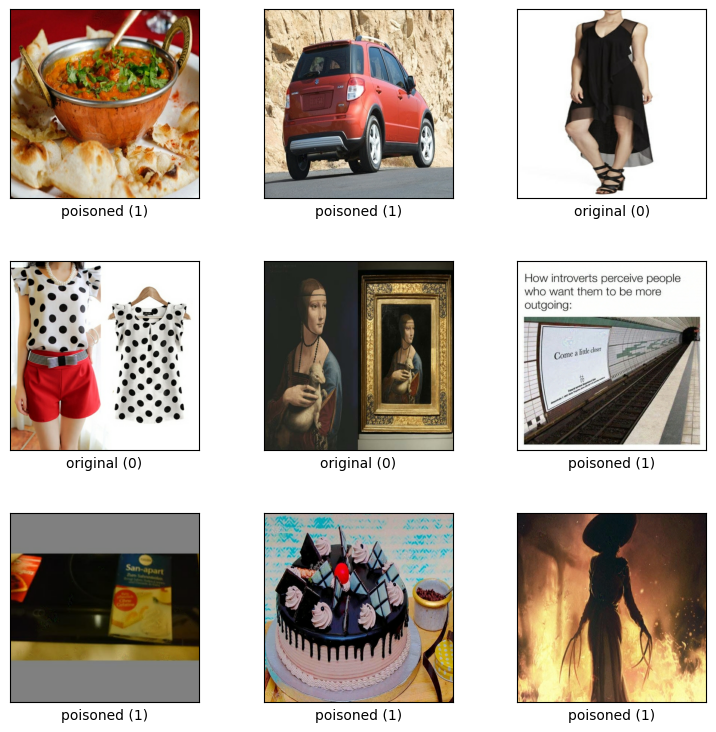

In [3]:
# load the dataset, print a summary and display some samples
# see https://www.tensorflow.org/datasets/api_docs/python/tfds
builder = tfds.ImageFolder('130kv2')
print(builder.info)  # num examples, labels... are automatically calculated
train_ds = builder.as_dataset(split='train', batch_size=batch_size, shuffle_files=True, as_supervised=True).prefetch(tf.data.AUTOTUNE)
test_ds = builder.as_dataset(split='test', batch_size=batch_size, shuffle_files=True, as_supervised=True).prefetch(tf.data.AUTOTUNE)
val_ds = builder.as_dataset(split='validation', batch_size=batch_size, shuffle_files=True, as_supervised=True).prefetch(tf.data.AUTOTUNE)
tfds.show_examples(train_ds, builder.info, True)

In [4]:
# add some minor augmentation, avoiding anything which might rescale or otherwise impact perturbations
# see https://keras.io/examples/vision/image_classification_from_scratch/
data_augmentation_layers = tf.keras.Sequential([
    #tf.keras.layers.Normalization(),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
])

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

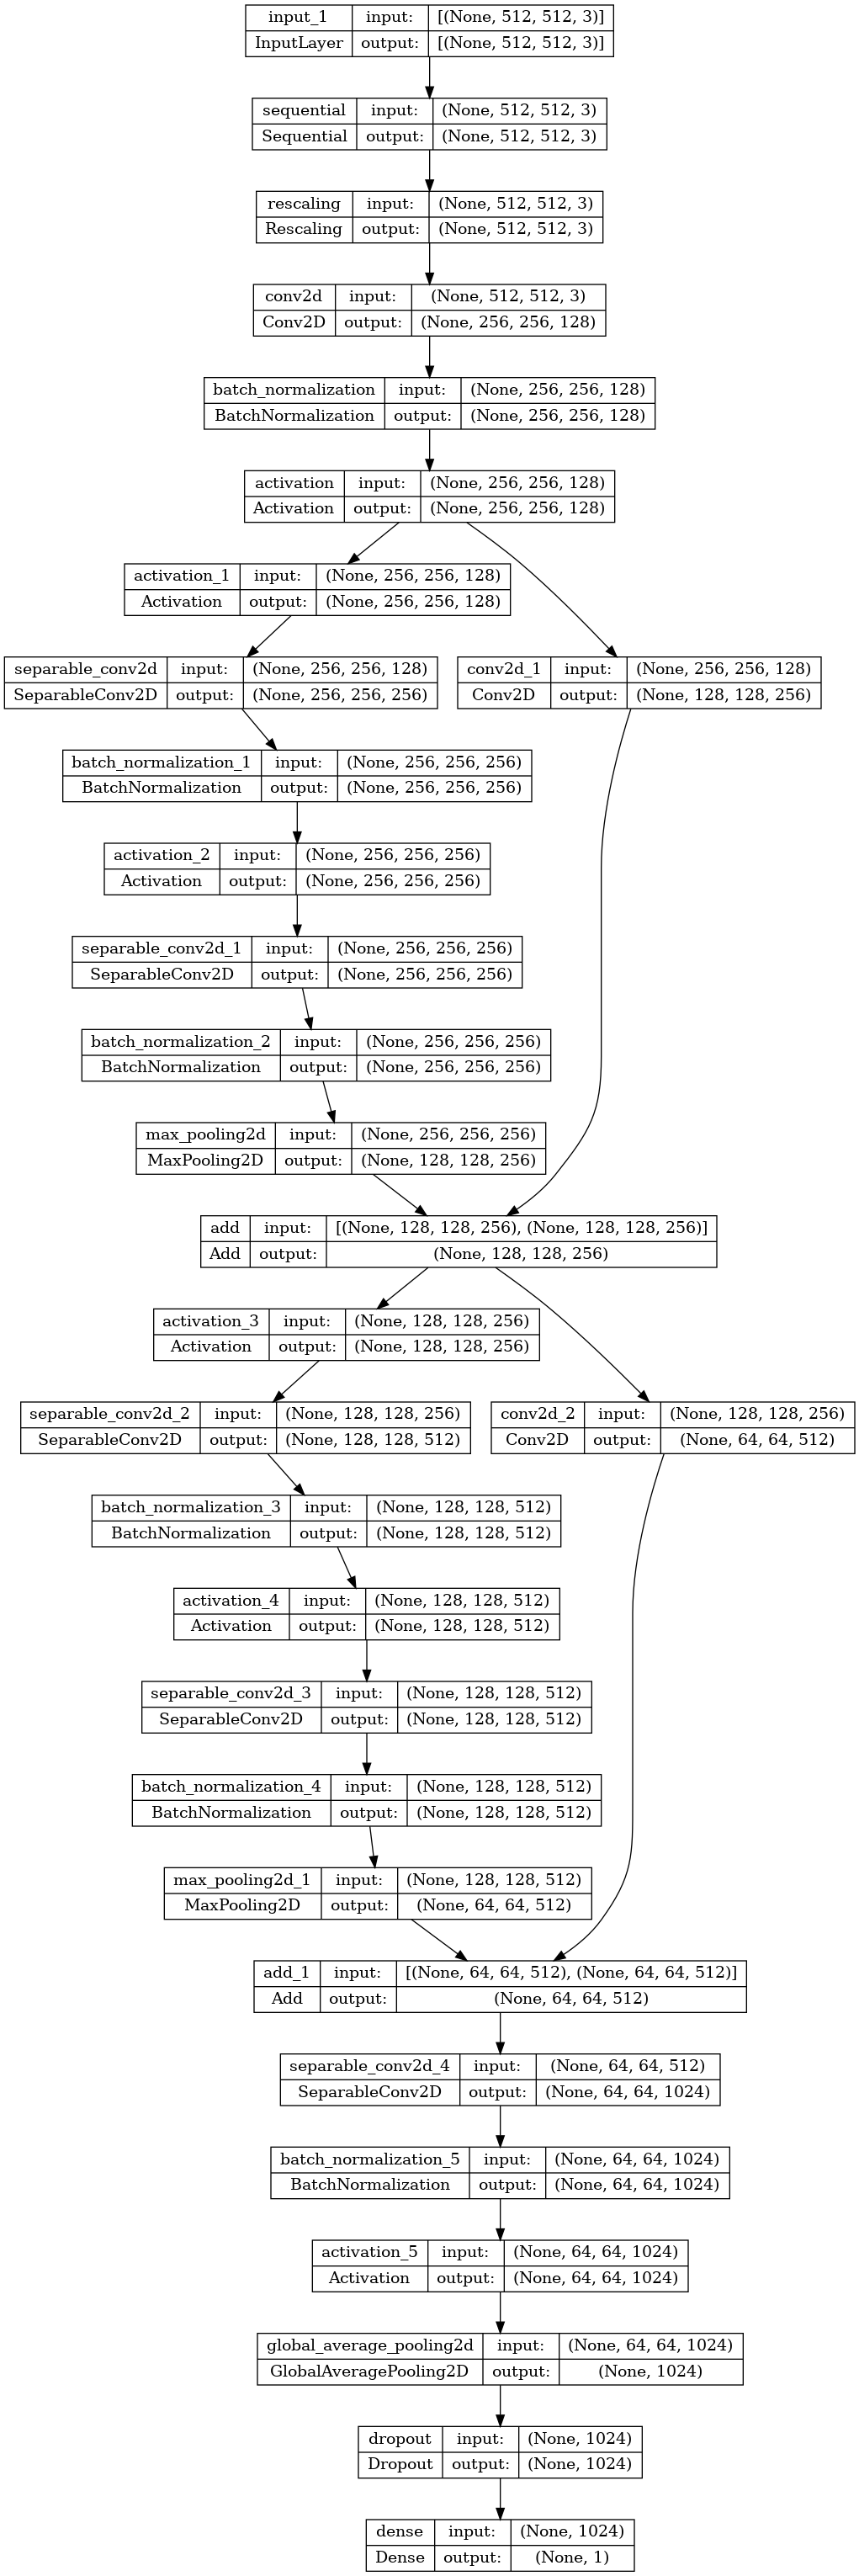

In [5]:
def make_model(input_shape, num_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Entry block
    x = data_augmentation_layers(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)
    x = tf.keras.layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    previous_block_activation = x  # Set aside residual

    for size in [256, 512, 768]:
        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.SeparableConv2D(size, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.Activation("relu")(x)
        x = tf.keras.layers.SeparableConv2D(size, 3, padding="same")(x)
        x = tf.keras.layers.BatchNormalization()(x)

        x = tf.keras.layers.MaxPooling2D(3, strides=2, padding="same")(x)

        # Project residual
        residual = tf.keras.layers.Conv2D(size, 1, strides=2, padding="same")(
            previous_block_activation
        )
        x = tf.keras.layers.add([x, residual])  # Add back residual
        previous_block_activation = x  # Set aside next residual

    x = tf.keras.layers.SeparableConv2D(1024, 3, padding="same")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation("relu")(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    if num_classes == 2:
        units = 1
    else:
        units = num_classes

    x = tf.keras.layers.Dropout(0.25)(x)
    # We specify activation=None so as to return logits
    outputs = tf.keras.layers.Dense(units, activation=None)(x)
    return tf.keras.Model(inputs, outputs)

model = make_model(input_shape=(image_size,image_size) + (3,), num_classes=2)
tf.keras.utils.plot_model(model, 'models/model.png', show_shapes=True)

In [6]:
epochs = 10

callbacks = [
    tf.keras.callbacks.ModelCheckpoint("models/save_at_{epoch}.keras"),
]
model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=[tf.keras.metrics.BinaryAccuracy(name="accuracy")],
)
model_history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=val_ds,
).history

Epoch 1/10


2024-03-28 21:21:01.112297: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:467] Loaded cuDNN version 90000
2024-03-28 21:21:05.773436: I external/local_xla/xla/service/service.cc:168] XLA service 0x7ff060306c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-03-28 21:21:05.773477: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2024-03-28 21:21:05.785456: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1711660865.873841   22543 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


385/385 [==============================] - 153s 354ms/step - loss: 0.7339 - accuracy: 0.4992 - val_loss: 0.6969 - val_accuracy: 0.5000
Epoch 2/10
385/385 [==============================] - 92s 239ms/step - loss: 0.7207 - accuracy: 0.4972 - val_loss: 0.7027 - val_accuracy: 0.5023
Epoch 3/10
385/385 [==============================] - 92s 240ms/step - loss: 0.6707 - accuracy: 0.5683 - val_loss: 0.7458 - val_accuracy: 0.6439
Epoch 4/10
385/385 [==============================] - 92s 240ms/step - loss: 0.5271 - accuracy: 0.7344 - val_loss: 0.6752 - val_accuracy: 0.7258
Epoch 5/10
385/385 [==============================] - 92s 239ms/step - loss: 0.4012 - accuracy: 0.8115 - val_loss: 1.0431 - val_accuracy: 0.5856
Epoch 6/10
385/385 [==============================] - 93s 241ms/step - loss: 0.3406 - accuracy: 0.8456 - val_loss: 0.8565 - val_accuracy: 0.6417
Epoch 7/10
385/385 [==============================] - 94s 244ms/step - loss: 0.2885 - accuracy: 0.8732 - val_loss: 0.8532 - val_accuracy: 0.


initial_model training history


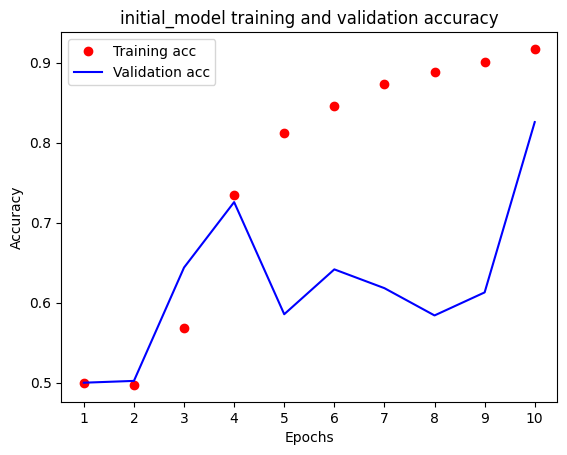

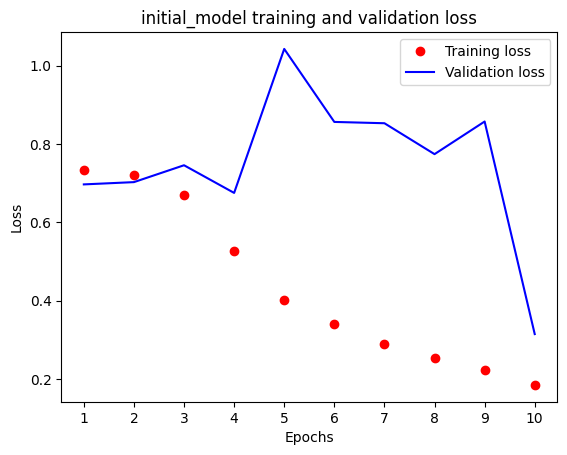

initial_model summary
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 512, 512, 3)]        0         []                            
                                                                                                  
 sequential (Sequential)     (None, None, None, 3)        0         ['input_1[0][0]']             
                                                                                                  
 rescaling (Rescaling)       (None, 512, 512, 3)          0         ['sequential[0][0]']          
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256, 128)        3584      ['rescaling[0][0]']           
                                                                        

In [8]:
#model = tf.keras.models.load_model('save_at_3.keras')
eval_results = eval_model('initial_model',model,model_history,val_ds,test_ds)
#model_history